In [1]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from anngeno import AnnGeno
# pl.Config.set_tbl_rows(15)

/home/dnanexus/anngeno/anngeno/anngeno.py:14: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


In [2]:
# Configuration and paths
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)

config_path = "/home/dnanexus/ukbgym/config_odds.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

# Read the variant consequence configuration
records = []
for group, consequences in config["variant_consequences"].items():
    for consequence in consequences:
        records.append({'variant_class': group, 'vep_consequence': consequence})
var_cons = pl.DataFrame(records)


# Use a list comprehension to flatten the nested dictionary into records
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#DD4344""","""LOFTEE HC""",1
"""missense""","""am_pathogenicity""","""#feb72d""","""AlphaMissense""",1
"""missense""","""score_pai3d""","""peru""","""PrimateAI-3D""",1
"""missense""","""esmscoremissense""","""#feb72d""","""ESM1v""",-1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
…,…,…,…,…
"""splicing""","""absplice_dna_max""","""#28a745""","""AbSplice (max)""",1
"""splicing""","""absplice2_max""","""#28a745""","""AbSplice2 (max)""",1
"""regulatory_nondir""","""promoterai_abs""","""#00A99D""","""PromoterAI abs""",1


In [ ]:
anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass394genes_olink371genes_annotated_MANE_CADD_251110.parquet")

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

# existing_annos = ['cadd_raw', 'gpn_score', 'gpn_star_llr_calibrated_mean']
# existing_annos = ['am_pathogenicity']

# Filter variant classes
variant_class = "non_coding"
consequences_for_group = var_cons.filter(
    pl.col('variant_class') == variant_class
)['vep_consequence'].to_list()
filter_expression = pl.any_horizontal(
    (pl.col(c) == 1) for c in consequences_for_group if c in anno.collect_schema().names()
)

# min_range = -500
# max_range = +0

anno = (
    anno
    .filter(
        (pl.col('vep_cds') == False) &
        (pl.col('mane_cds') == False) &
        (pl.col('non_mane_cds') == False) &
        
        # filter_expression &
        # (
        #     (pl.col('consequence_splice_donor_variant') == 0) &
        #     (pl.col('consequence_splice_acceptor_variant') == 0) &
        #     (pl.col('consequence_splice_region_variant') == 0) &
        #     (pl.col('consequence_splice_donor_5th_base_variant') == 0) &
        #     (pl.col('consequence_splice_donor_region_variant') == 0) &
        #     (pl.col('consequence_splice_polypyrimidine_tract_variant') == 0)
        # ) &
        # (
        #     (pl.col('consequence_splice_donor_variant') == 0) &
        #     (pl.col('consequence_splice_acceptor_variant') == 0)
        #     (pl.col('consequence_start_retained_variant') == 0) &
        #     (pl.col('consequence_start_lost') == 0)
        # ) &
        
        # Distance to TSS range
        # (pl.col('dist_to_tss') >= min_range) &

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .select(
        set(['id', 'region', 'tss', 'strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
)

anno

am_pathogenicity,absplice_dna_max,mamphylop,region,loftee_hc,score_pai3d,dist_to_tss,gene_name,id,promoterai,gene_length,delta_score,gpn_star_llr_calibrated_mean,cadd_raw,pangolin_score,absplice2_max,tss,gpn_score,strand,verphylop,esmscoremissense
f32,f64,f32,str,i8,f32,i64,str,str,f32,i64,f64,f32,f32,f64,f64,i64,f32,str,f32,f32
null,0.001,-1.301,"""ENSG00000163554""",0,null,57135,"""SPTA1""","""chr1:158629580:T:C""",null,76013,0.0,1.896398,-0.283735,0.0,0.000033,158686715,0.9,"""-1""",-1.395,null
null,0.001,1.346,"""ENSG00000163554""",0,null,68443,"""SPTA1""","""chr1:158618272:G:A""",null,76013,0.0,-0.285355,0.665707,0.0,0.000033,158686715,-1.31,"""-1""",1.209,null
null,0.001,-0.322,"""ENSG00000163554""",0,null,68287,"""SPTA1""","""chr1:158618428:C:T""",null,76013,0.0,-0.573519,0.329809,0.0,0.000033,158686715,-0.86,"""-1""",-0.297,null
null,0.001,0.306,"""ENSG00000163554""",0,null,64266,"""SPTA1""","""chr1:158622449:T:G""",null,76013,0.0,-0.520327,0.390204,0.0,0.000033,158686715,-1.46,"""-1""",0.323,null
null,0.001,0.063,"""ENSG00000163554""",0,null,62297,"""SPTA1""","""chr1:158624418:C:T""",null,76013,0.0,0.896379,0.616764,0.0,0.000033,158686715,-0.04,"""-1""",0.063,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
null,null,null,"""ENSG00000106991""",0,null,48511,"""ENG""","""chr9:127806147:T:A""",null,39647,null,-0.126151,0.320896,null,null,127854658,-2.39,"""-1""",null,null
null,null,null,"""ENSG00000106991""",0,null,48132,"""ENG""","""chr9:127806526:T:C""",null,39647,null,-0.184873,-0.084201,null,null,127854658,-1.33,"""-1""",null,null
null,null,null,"""ENSG00000106991""",0,null,45640,"""ENG""","""chr9:127809018:G:C""",null,39647,null,-1.882955,1.129233,null,null,127854658,-4.25,"""-1""",null,null


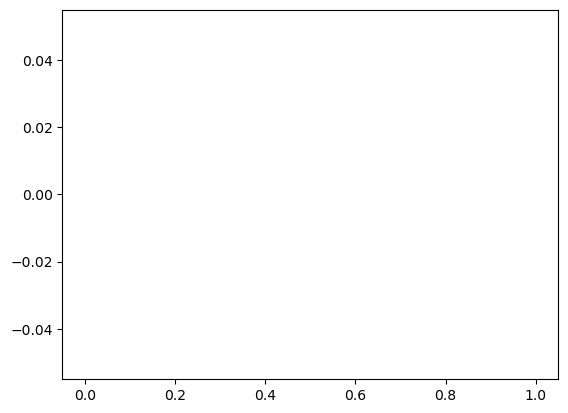

In [4]:
plt.hist(anno['am_pathogenicity'].drop_nulls(), bins=100)
plt.show()

In [5]:
melted_anno = (
    anno.unpivot(
        index=["id", "region"],
        on=existing_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df,
        on="annotation",
        how="left"
    )

    .filter(
        # Remove null annotation scores
        (pl.col('annotation_score').is_not_null()) &

        # Filter based on category
        # pl.col('category').is_in(['genetic_diversity', 'splicing', 'conservation', 'missense'])
        (pl.col('category').is_in(['genetic_diversity', 'splicing', 'conservation']))
    )

    .with_columns(
        annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir").cast(pl.Float32)
    )
    
    # Implement filtering based on the defined percentile
    .with_columns(
        annotation_score_dircor_rank = pl.col('annotation_score_dircor').rank(method="average").over(["region", "annotation"]).cast(pl.Float32),
        anno_score_count = pl.len().over(["region", "annotation"]).cast(pl.Int32)
    )
    .with_columns(
        annotation_score_dircor_ptile = pl.col('annotation_score_dircor_rank') / pl.col('anno_score_count').round(4).cast(pl.Float32)
    )
    .drop(['anno_score_count', 'annotation_score_dircor'])
)

melted_anno

id,region,annotation,annotation_score,category,color,label,annotation_dir,annotation_score_dircor_rank,annotation_score_dircor_ptile
str,str,str,f32,str,str,str,i8,f32,f32
"""chr1:158629580:T:C""","""ENSG00000163554""","""cadd_raw""",-0.283735,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,4477.0,0.150069
"""chr1:158618272:G:A""","""ENSG00000163554""","""cadd_raw""",0.665707,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,27306.0,0.915295
"""chr1:158618428:C:T""","""ENSG00000163554""","""cadd_raw""",0.329809,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,21294.0,0.713773
"""chr1:158622449:T:G""","""ENSG00000163554""","""cadd_raw""",0.390204,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,22924.0,0.768411
"""chr1:158624418:C:T""","""ENSG00000163554""","""cadd_raw""",0.616764,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,26765.0,0.897161
…,…,…,…,…,…,…,…,…,…
"""chr10:116115980:C:T""","""ENSG00000151892""","""absplice2_max""",0.000034,"""splicing""","""#28a745""","""AbSplice2 (max)""",1,69072.5,0.878673
"""chr10:116104870:T:A""","""ENSG00000151892""","""absplice2_max""",0.000033,"""splicing""","""#28a745""","""AbSplice2 (max)""",1,33243.5,0.422891
"""chr10:116109612:G:A""","""ENSG00000151892""","""absplice2_max""",0.000033,"""splicing""","""#28a745""","""AbSplice2 (max)""",1,33243.5,0.422891


In [6]:
ptile_counts_df = (
    melted_anno
    .group_by(['annotation', 'annotation_score_dircor_ptile'])
    .agg(
        n_vars_at_ptile = pl.len()
    )
    .sort('annotation_score_dircor_ptile', descending=True)
    .with_columns(
        n_vars_above_ptile = pl.col('n_vars_at_ptile').cum_sum().over('annotation')
    )
)

melted_anno = melted_anno.join(ptile_counts_df, on=['annotation', 'annotation_score_dircor_ptile'], how='inner')
melted_anno

id,region,annotation,annotation_score,category,color,label,annotation_dir,annotation_score_dircor_rank,annotation_score_dircor_ptile,n_vars_at_ptile,n_vars_above_ptile
str,str,str,f32,str,str,str,i8,f32,f32,u64,u64
"""chr1:158629580:T:C""","""ENSG00000163554""","""cadd_raw""",-0.283735,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,4477.0,0.150069,1,18731147
"""chr1:158618272:G:A""","""ENSG00000163554""","""cadd_raw""",0.665707,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,27306.0,0.915295,3,1867069
"""chr1:158618428:C:T""","""ENSG00000163554""","""cadd_raw""",0.329809,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,21294.0,0.713773,2,6308206
"""chr1:158622449:T:G""","""ENSG00000163554""","""cadd_raw""",0.390204,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,22924.0,0.768411,3,5104092
"""chr1:158624418:C:T""","""ENSG00000163554""","""cadd_raw""",0.616764,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,26765.0,0.897161,2,2266701
…,…,…,…,…,…,…,…,…,…,…,…
"""chr10:116115980:C:T""","""ENSG00000151892""","""absplice2_max""",0.000034,"""splicing""","""#28a745""","""AbSplice2 (max)""",1,69072.5,0.878673,5128,1880960
"""chr10:116104870:T:A""","""ENSG00000151892""","""absplice2_max""",0.000033,"""splicing""","""#28a745""","""AbSplice2 (max)""",1,33243.5,0.422891,66486,7300911
"""chr10:116109612:G:A""","""ENSG00000151892""","""absplice2_max""",0.000033,"""splicing""","""#28a745""","""AbSplice2 (max)""",1,33243.5,0.422891,66486,7300911


In [7]:
ct_df = melted_anno.group_by('annotation').agg(
    n_vars = pl.len(),
    max_ptile = pl.col('annotation_score_dircor_ptile').max(),
).sort('n_vars', descending=True)

assert ct_df['max_ptile'].min() == 1.0
ct_df

annotation,n_vars,max_ptile
str,u64,f32
"""gpn_score""",22038043,1.0
"""gpn_star_llr_calibrated_mean""",22038043,1.0
"""cadd_raw""",22038043,1.0
"""mamphylop""",21897598,1.0
"""verphylop""",21897598,1.0
"""absplice2_max""",15642660,1.0
"""pangolin_score""",15642580,1.0
"""absplice_dna_max""",13818201,1.0
"""delta_score""",13695101,1.0


In [8]:
appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_quantitative_EUR_genebass1e6_PRScorr_with_percentiles.parquet")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
        .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value_ptile', 'n_individuals']
    )
)

# unique_phenotypes = appv.select('phenotype').unique().collect(engine='streaming').to_series()

In [9]:
# Get gene trait associations

plof = pl.read_parquet('/home/dnanexus/data_dir/association_files/rvat_EUR_500k_regenie.parquet').with_columns(
    phenotype = (pl.col('trait') + '_int'),
    region = pl.col('gene_id'),
    rvat_pval = (10** -pl.col("neg_log10p")),
).filter(
    (pl.col('trait_type') == 'quantitative')
)

loftee_corr = pl.read_parquet("/home/dnanexus/data_dir/association_files/loftee_correlation_quantitative_wgs_EUR_genebass1e6_maf1e3_snp_consistent.parquet")

gene_trait_df = loftee_corr.join(plof[['region', 'phenotype', 'beta', 'rvat_pval']], on=['region', 'phenotype'], how='inner').filter(
    pl.col('loftee_corr')*pl.col('beta') > 0
).with_columns(
    corr_dir = pl.col('loftee_corr')/pl.col('loftee_corr').abs()
)

# gene_trait_df = gene_trait_df.head()
# gene_trait_df = gene_trait_df.filter(
#     pl.col('gene_name') == "LDLR",
#     pl.col('phenotype') == "ldl_direct_int",
# )
gene_trait_df

region,gene_name,phenotype,loftee_corr,n_variants,beta,rvat_pval,corr_dir
str,str,str,f64,u64,f64,f64,f64
"""ENSG00000116183""","""PAPPA2""","""arm_fatfree_mass_right_int""",-0.014747,82603,-0.195409,9.1637e-8,-1.0
"""ENSG00000129083""","""COPB1""","""arm_fatfree_mass_right_int""",-0.014338,13594,-0.397279,0.006626,-1.0
"""ENSG00000100578""","""KIAA0586""","""arm_fatfree_mass_right_int""",-0.010787,28541,-0.058463,0.000305,-1.0
"""ENSG00000157766""","""ACAN""","""arm_fatfree_mass_right_int""",-0.036259,20244,-0.436618,6.0395e-11,-1.0
"""ENSG00000140443""","""IGF1R""","""arm_fatfree_mass_right_int""",-0.013644,82469,-0.412619,2.8609e-8,-1.0
…,…,…,…,…,…,…,…
"""ENSG00000112077""","""RHAG""","""reticulocyte_count_int""",0.033239,9849,0.952411,1.8038e-41,1.0
"""ENSG00000029534""","""ANK1""","""reticulocyte_count_int""",0.02685,54620,0.656849,2.1682e-10,1.0
"""ENSG00000197969""","""VPS13A""","""reticulocyte_count_int""",0.003971,55477,0.176348,2.1188e-7,1.0


## Odds ratio computation

In [ ]:
n_steps = 100
min_rank_cutoff = 1_000
max_rank_cutoff = 1_000_000
or_threshold_pheno = 0.99

cutoffs_list = np.geomspace(
# cutoffs_list = np.linspace(
    min_rank_cutoff, 
    max_rank_cutoff, 
    num=n_steps
).tolist()

cutoffs_lazy = pl.LazyFrame({"rank_cutoff": cutoffs_list})

cutoffs_lazy.collect()

rank_cutoff
f64
1000.0
1035.321843
1071.891319
1109.752496
1148.951
…
870359.136149
901101.825167
932930.402628


In [11]:
# --- 1. Lazily prepare the filter keys ---
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = melted_anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())


# --- Build main query (same as before, but stop before group_by) ---
gp_lazy = (
    appv
    .join(anno_ids_lazy, on="id", how="semi")
    .join(
        melted_anno.lazy().drop([c for c in melted_anno.columns if 'is_nan' in c]), 
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )
    .with_columns(
        mean_pheno_value_dircor_ptile = pl.when(pl.col('corr_dir') == -1)
            .then(1 - pl.col('mean_pheno_value_ptile'))
            .otherwise(pl.col('mean_pheno_value_ptile')),
    )
)

# Cross join with cutoffs and compute odds ratios
or_lazy = (
    gp_lazy
    .select(["annotation", "region", "gene_name", "phenotype", "n_vars_above_ptile", "mean_pheno_value_dircor_ptile"])
    .join(cutoffs_lazy, how="cross")
    .group_by(["annotation", "region", "gene_name", "phenotype", "rank_cutoff"])
    .agg(
        n_dis_above_cutoff = (
            (pl.col("n_vars_above_ptile") <= pl.col("rank_cutoff")) & 
            (pl.col("mean_pheno_value_dircor_ptile") >= or_threshold_pheno)
        ).sum(),
        n_notdis_above_cutoff = (
            (pl.col("n_vars_above_ptile") <= pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_dircor_ptile") < or_threshold_pheno)
        ).sum(),
        n_dis_below_cutoff = (
            (pl.col("n_vars_above_ptile") > pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_dircor_ptile") >= or_threshold_pheno)
        ).sum(),
        n_notdis_below_cutoff = (
            (pl.col("n_vars_above_ptile") > pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_dircor_ptile") < or_threshold_pheno)
        ).sum()
    )
    .with_columns(
        # odds_ratio = ((pl.col("n_dis_above_cutoff") + 1) / (pl.col("n_notdis_above_cutoff")+1)) / (1 - or_threshold_pheno)
        odds_ratio = (pl.col("n_dis_above_cutoff") / pl.col("n_notdis_above_cutoff")) / (pl.col("n_dis_below_cutoff") / pl.col("n_notdis_below_cutoff"))
    )
)

# Execute
print("Executing with odds ratios...")
or_df = or_lazy.collect(engine='streaming').sort('rank_cutoff')

or_df.write_parquet(f'/home/dnanexus/data_dir/results/odds_ratio_{or_threshold_pheno}_ranks_{min_rank_cutoff}_wgs_EUR_genebass1e6_maf1e3.parquet')

or_df

Executing with odds ratios...


annotation,region,gene_name,phenotype,rank_cutoff,n_dis_above_cutoff,n_notdis_above_cutoff,n_dis_below_cutoff,n_notdis_below_cutoff,odds_ratio
str,str,str,str,f64,u64,u64,u64,u64,f64
"""cadd_raw""","""ENSG00000196739""","""COL27A1""","""arm_fatfree_mass_left_int""",1000.0,0,1,371,34648,0.0
"""pangolin_score""","""ENSG00000178252""","""WDR6""","""arm_predicted_mass_right_int""",1000.0,0,1,12,1254,0.0
"""mamphylop""","""ENSG00000101004""","""NINL""","""creatinine_int""",1000.0,0,3,315,29309,0.0
"""cadd_raw""","""ENSG00000185950""","""IRS2""","""cystatin_c_int""",1000.0,0,0,76,8218,NaN
"""gpn_score""","""ENSG00000169047""","""IRS1""","""forced_expiratory_volume_in_1s…",1000.0,0,1,143,14092,0.0
…,…,…,…,…,…,…,…,…,…
"""absplice2_max""","""ENSG00000118702""","""GHRH""","""whole_body_fatfree_mass_int""",1e6,3,136,21,2111,2.217437
"""gpn_score""","""ENSG00000138685""","""FGF2""","""whole_body_water_mass_int""",1e6,11,703,174,15205,1.367334
"""cadd_raw""","""ENSG00000100578""","""KIAA0586""","""whole_body_water_mass_int""",1e6,17,1213,271,25915,1.340201


## Plotting

In [12]:
# or_df = pl.read_parquet(f'/home/dnanexus/data_dir/results/odds_ratio_all_vars_{or_threshold_pheno}_wgs_EUR_genebass1e6_maf1e3.parquet')

print('unique percentile cutoffs:', or_df['rank_cutoff'].n_unique())

plt_df = (
    or_df
    .drop_nans()
    .filter(pl.col("odds_ratio").is_finite())
    .with_columns(
        n_gene_phenos = pl.len().over(['rank_cutoff', 'annotation']),
    )
    .with_columns(
        med_odds_ratio = pl.col('odds_ratio').median().over(['rank_cutoff', 'annotation']),
        avg_odds_ratio = pl.col('odds_ratio').mean().over(['rank_cutoff', 'annotation']),
        se_odds_ratio = pl.col('odds_ratio').std().over(['rank_cutoff', 'annotation'])/(pl.col('n_gene_phenos').sqrt()),
    )
    .with_columns(
        std_ci_upper = pl.col('avg_odds_ratio') + 1.96 * (pl.col('se_odds_ratio')),
        std_ci_lower = pl.col('avg_odds_ratio') - 1.96 * (pl.col('se_odds_ratio')),
    )
    .select(['annotation', 'rank_cutoff', 'n_gene_phenos', 'med_odds_ratio', 'avg_odds_ratio', 'se_odds_ratio', 'std_ci_upper', 'std_ci_lower'])
    .unique()
    .join(
        anno_config_df.select(['annotation', 'color', 'label']),
        on='annotation',
        how='left'
    )
    .sort('rank_cutoff')
)

plt_df

unique percentile cutoffs: 200


annotation,rank_cutoff,n_gene_phenos,med_odds_ratio,avg_odds_ratio,se_odds_ratio,std_ci_upper,std_ci_lower,color,label
str,f64,u64,f64,f64,f64,f64,f64,str,str
"""gpn_star_llr_calibrated_mean""",1000.0,880,0.0,1.069399,0.325974,1.708308,0.43049,"""#942c80""","""GPN-Star"""
"""gpn_score""",1000.0,685,0.0,1.267453,0.380254,2.01275,0.522155,"""#942c80""","""GPN-MSA"""
"""absplice_dna_max""",1000.0,788,0.0,3.282661,0.511223,4.284658,2.280663,"""#28a745""","""AbSplice (max)"""
"""verphylop""",1000.0,770,0.0,0.968363,0.313129,1.582097,0.35463,"""#942c80""","""Vertebrate PhyloP"""
"""delta_score""",1000.0,883,0.0,1.495654,0.478148,2.432825,0.558483,"""green""","""SpliceAI"""
…,…,…,…,…,…,…,…,…,…
"""gpn_score""",1e6,1176,1.129765,1.250684,0.019928,1.289743,1.211624,"""#942c80""","""GPN-MSA"""
"""delta_score""",1e6,1144,1.066111,1.240307,0.056012,1.35009,1.130524,"""green""","""SpliceAI"""
"""cadd_raw""",1e6,1176,1.111002,1.21829,0.020149,1.257783,1.178797,"""#1f77b4""","""CADD Raw"""


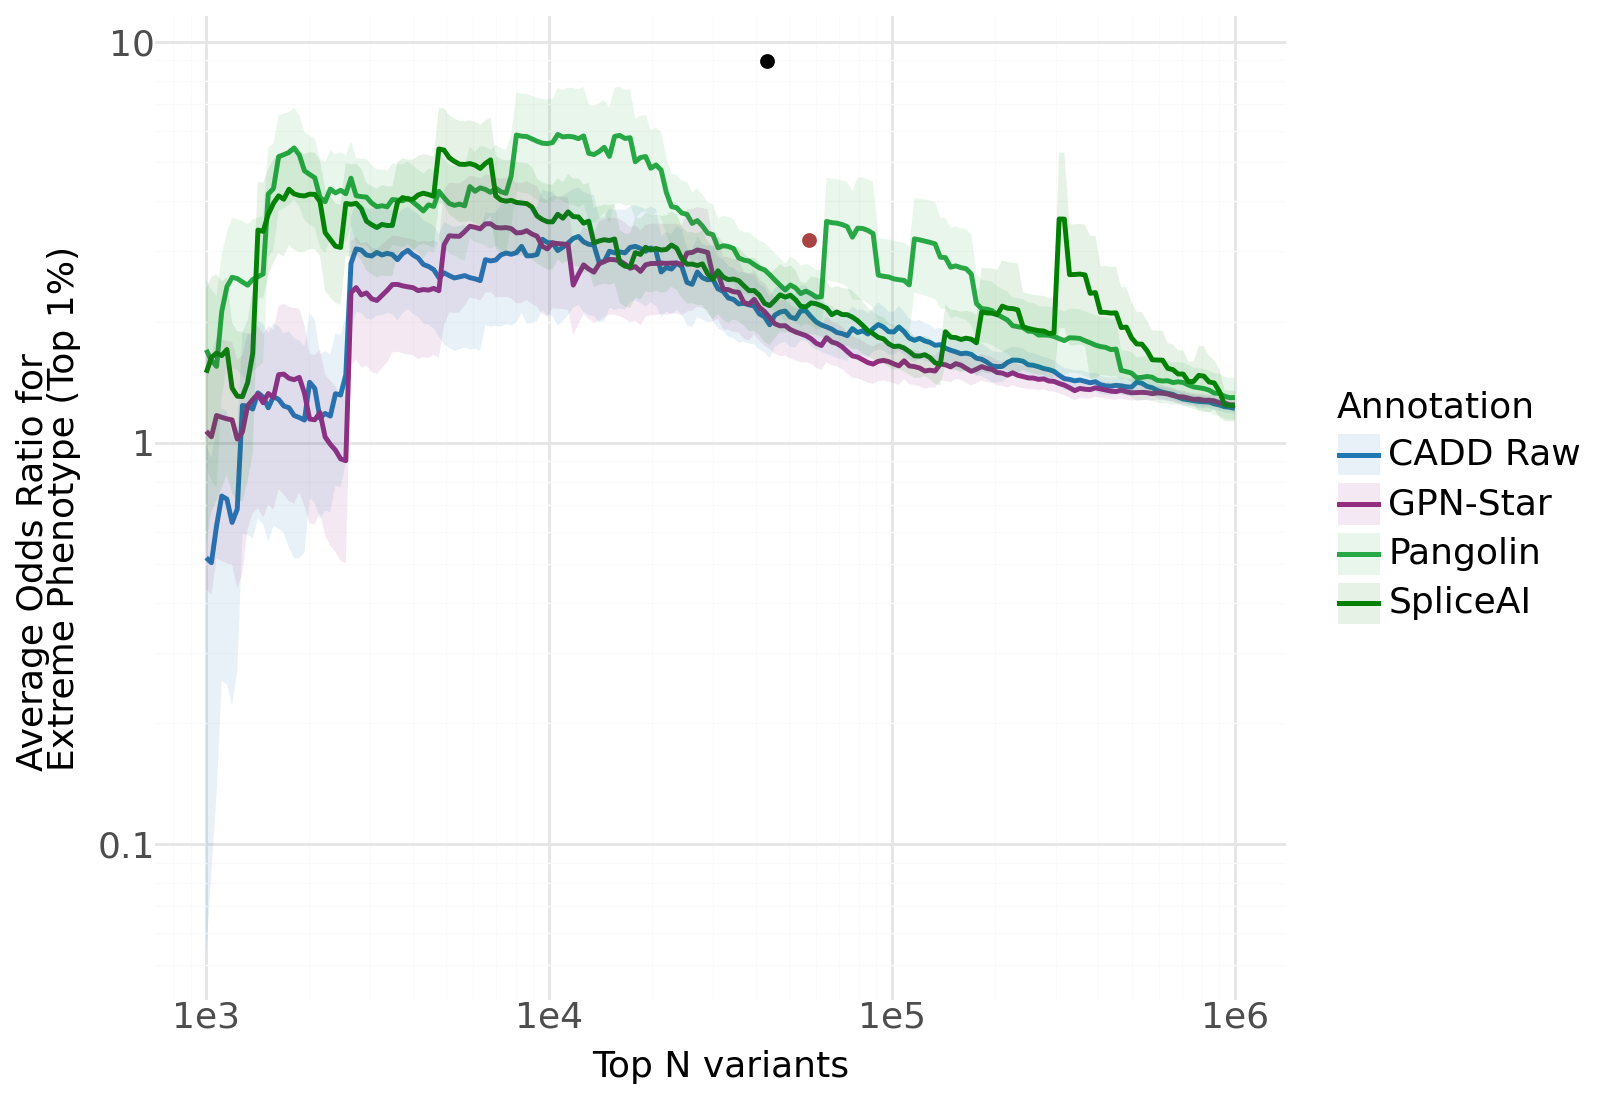

In [13]:
color_dict = dict(zip(plt_df['label'], plt_df['color']))

# am_lof_df = pl.DataFrame({
#     'annotation': ['loftee_coding', 'am_0.8_coding'],
#     'n_vars': [21519, 56609],
#     'mean_or': [6.874422, 2.323273],
#     'median_or': [3.04127, 1.770242],
# })

am_lof_df = pl.DataFrame({
    'annotation': ['loftee_coding', 'am_0.8_coding'],
    'n_vars': [43179, 57191],
    'mean_or': [8.963194, 3.196688],
    'median_or': [3.724961, 1.955789],
})

(
    ggplot(
        # plt_df,
        # plt_df.filter(pl.col('annotation').is_in(['cadd_raw', 'gpn_star_llr_calibrated_mean', 'pangolin_score', 'delta_score', 'am_pathogenicity', 'score_pai3d'])),
        plt_df.filter(pl.col('annotation').is_in(['cadd_raw', 'gpn_star_llr_calibrated_mean', 'pangolin_score', 'delta_score'])),
        aes(x='rank_cutoff', y='avg_odds_ratio')
    )
    + geom_line(aes(color='label'), size=1)
    + geom_point(am_lof_df.filter(pl.col('annotation')=='loftee_coding'), aes(x='n_vars', y='mean_or'), color='black', size=2)
    + geom_point(am_lof_df.filter(pl.col('annotation')=='am_0.8_coding'), aes(x='n_vars', y='mean_or'), color='#AA4344', size=2)
    + geom_ribbon(aes(ymin='std_ci_lower', ymax='std_ci_upper', fill='label'), alpha=0.1)
    + scale_fill_manual(values=color_dict)
    + scale_color_manual(values=color_dict)
    + labs(
        y="Average Odds Ratio for\nExtreme Phenotype (Top 1%)",
        x="Top N variants",
        color="Annotation",
        fill="Annotation",
    )
    + scale_x_log10()
    + scale_y_log10()
    + theme_minimal()
    + theme(
        figure_size=(8, 5.5),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
    )
)

In [16]:
plt_df.filter(pl.col('annotation')=='am_pathogenicity').filter(pl.col('avg_odds_ratio')>=1)

annotation,rank_cutoff,n_gene_phenos,med_odds_ratio,avg_odds_ratio,se_odds_ratio,std_ci_upper,std_ci_lower,color,label
str,f64,u64,f64,f64,f64,f64,f64,str,str


In [17]:
(
    melted_anno
    .filter(
        pl.col('annotation')=='am_pathogenicity',
        pl.col('n_vars_above_ptile') > 360000.0,
    )
    .sort('annotation_score')
)

id,region,annotation,annotation_score,category,color,label,annotation_dir,annotation_score_dircor_rank,annotation_score_dircor_ptile,n_vars_at_ptile,n_vars_above_ptile
str,str,str,f32,str,str,str,i8,f32,f32,u64,u64
